# 01 — BERTopic em AG News (canonical, EN)

## O que esse notebook faz

Aplica **BERTopic (Grootendorst 2022)** ao corpus AG News (~127k notícias em inglês, 4 categorias canônicas: World, Sports, Business, Sci/Tech) para descobrir tópicos via pipeline neural:

```
embeddings semânticos → UMAP 5D → HDBSCAN → c-TF-IDF → MMR diversity
```

## Por que AG News como corpus de validação BERTopic

- **Volume alto** (~127k docs) testa BERTopic em escala — vs ~2.6k do piloto Raquel Lyra (5x maior em magnitude).
- **Ground-truth implícito**: 4 categorias balanceadas servem como validação de cobertura temática.
- **Inglês** — testa pipeline na trilha EN (Reuters cobriu LDA/STM em EN; AG News valida BERTopic semântico).
- **Headlines + descrição curtos** (~38 tokens/doc avg) — diferente do Reuters (artigos longos 131 tokens) e Folha (artigos full 700+ tokens). Ajuda a calibrar BERTopic em diferentes regimes de tamanho.

## Pipeline BERTopic neste notebook

1. Carrega `corpus_limpo.csv` (127.593 docs)
2. Embeddings via Ollama `qwen3-embedding:0.6b` (1024d nativo, Matryoshka desabilitado) — cached em .npy
3. BERTopic com:
   - **UMAP**: n_components=5, n_neighbors=15, metric=cosine, random_state=42
   - **HDBSCAN**: min_cluster_size=15, cluster_selection_method=leaf
   - **CountVectorizer**: ngram_range=(1,2), token_pattern ASCII EN
   - **MaximalMarginalRelevance**: diversity=0.2 (filtro suave de redundância morfológica)
   - **min_topic_size=25**
4. **Pós-processamento**: `reduce_topics(nr_topics=30)` + `reduce_outliers(strategy='c-tf-idf')`
5. Naming via `gemma4:e4b` (Ollama)
6. Métricas: c_v, exclusivity, topic_diversity, outlier_rate
7. Visualizações: wordclouds, theta heatmap, cross-tab × AG News categories, UMAP 2D

## Output esperado

`data/output/ag_news/{bertopic_results.csv, bertopic_topics_for_eval.csv, bertopic_metrics.csv, bertopic_model/}`.

## 1. Setup

In [ ]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import get_or_compute_embeddings
from _helpers import name_all_topics
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_topic_diversity,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


In [ ]:
# Cell 2 — Params
CORPUS_ID = "ag_news"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {cfg.get('language', 'en')}")
print(f"seed = {seed}")

## 2. AG News — corpus

### Origem

- **Fonte**: HuggingFace `datasets.load_dataset('ag_news')` (Zhang et al. 2015)
- **Adapter**: `01-preprocessing/src/adapters/ag_news.py`
- **Schema**: `post_id, message, date, category, lang`
- **4 categorias canônicas**: World, Sports, Business, Sci/Tech (balanceadas ~32k cada)

### Limitação

- **Sem date granular**: AG News não expõe data por artigo. Para BERTopic, irrelevante (não usa data); para análise temporal, aceitar limitação.

In [ ]:
# Cell 3 — Load corpus
_corpus_dir = f"../data/input/{CORPUS_ID}/"

df = load_corpus(_corpus_dir)
docs = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

print(f"Total docs: {len(docs):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)


In [ ]:
# Cell 4 — Estatisticas + distribuicao categorias
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=50, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--",
                label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--",
                label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts()
axes[1].bar(cat_counts.index, cat_counts.values, color="steelblue")
axes[1].set_xlabel("Categoria"); axes[1].set_ylabel("# documentos")
axes[1].set_title("Distribuição das 4 categorias AG News (ground-truth)")
for i, c in enumerate(cat_counts.values):
    axes[1].text(i, c + max(cat_counts)*0.01, f"{c:,}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")

## 3. Embeddings semânticos

### Modelo

`qwen3-embedding:0.6b` via Ollama, dimensão 1024d nativo (Matryoshka desabilitado).

- **Janela contextual**: 32k tokens (cobre AG News com folga; máximo 38 tokens/doc)
- **Multilinguismo**: nativo em 100+ idiomas (validado em PT-BR e EN no projeto)
- **Backend**: Ollama HTTP (paralelo, 5 concurrent calls por padrão)

### Cache

Embeddings são salvos em `data/input/ag_news/embeddings_<model>_1024d.npy`. Reuse automático se cache existir e shape bater.

In [ ]:
# Cell 5 — Embeddings (com cache)
bert_cfg = params["bertopic"]
emb_model = bert_cfg["embedding_model"]
emb_dim = bert_cfg.get("embedding_dimension")  # None → 1024d nativo
backend = bert_cfg.get("embedding_backend", "ollama")

safe_model = re.sub(r'[/:\\?*"<>|]', '_', emb_model)
cache_path = f"../data/input/{CORPUS_ID}/embeddings_{safe_model}_1024d.npy"

print(f"backend={backend}")
print(f"model={emb_model}")
print(f"dim={emb_dim or '1024d nativo'}")
print(f"cache_path={cache_path}")

t0 = time.time()
embeddings = get_or_compute_embeddings(
    texts=docs,
    model_name=emb_model,
    cache_path=cache_path,
    backend=backend,
    dimension=emb_dim,
    show_progress=True,
)
print(f"\nshape: {embeddings.shape}")
print(f"L2 norms (sample): {np.linalg.norm(embeddings[:5], axis=1)}")
print(f"tempo: {time.time()-t0:.0f}s")


## 4. BERTopic — fit + pós-processamento

### Decisões metodológicas (vide CLAUDE.md M1-M6, F1-F2 do piloto)

| Componente | Configuração | Por quê |
|---|---|---|
| `language` | `"english"` | AG News é EN; permite stripping ASCII + stop words EN nativas |
| UMAP | `n_components=5, n_neighbors=15, metric=cosine` | configuração canônica BERTopic; cosine é métrica ideal para embeddings normalizados |
| HDBSCAN | `min_cluster_size=15, cluster_selection_method=leaf` | granularidade fina, alinhada a `granularity=unit` |
| CountVectorizer | `ngram_range=(1,2)` + `min_df=5, max_df=0.5` | inclui bigrams; corte estatístico vs stop words manuais |
| MMR diversity | `0.2` | filtro suave de redundância morfológica (ex.: "report"/"reports") |
| `min_topic_size` | `25` | filtra nichos pequenos com sinal fraco |
| `reduce_topics(nr=30)` | pos-processamento | consolida granularidade fina |
| `reduce_outliers(c-tf-idf)` | pós-processamento | absorve outliers para cobertura ~100% |

In [ ]:
# Cell 6 — Configurar componentes BERTopic
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

vec_params = bert_cfg["vectorizer"]
vectorizer = CountVectorizer(
    ngram_range=tuple(vec_params["ngram_range"]),
    token_pattern=cfg.get("token_pattern", r"(?u)\b\w\w+\b"),
    stop_words="english",
    min_df=5, max_df=0.5,
)

umap_params = bert_cfg["umap"]
umap_model = UMAP(
    n_components=umap_params["n_components"],
    n_neighbors=umap_params["n_neighbors"],
    min_dist=umap_params["min_dist"],
    metric=umap_params["metric"],
    random_state=seed,
    verbose=True,
)

hdbscan_params = bert_cfg["hdbscan"]
hdbscan_model = HDBSCAN(
    min_cluster_size=hdbscan_params["min_cluster_size"],
    min_samples=hdbscan_params["min_samples"],
    cluster_selection_method=hdbscan_params["cluster_selection_method"],
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    representation_model=MaximalMarginalRelevance(diversity=bert_cfg["mmr_diversity"]),
    min_topic_size=bert_cfg["min_topic_size"],
    language=cfg.get("bertopic_language", "english"),
    calculate_probabilities=False,
    verbose=True,
)
print("BERTopic configurado.")

In [ ]:
# Cell 7 — Fit (UMAP + HDBSCAN clustering)
t0 = time.time()
topics, _ = topic_model.fit_transform(docs, embeddings)
print(f"\nfit_transform done in {time.time()-t0:.0f}s")

raw_n_topics = len(set(topics))
raw_outlier_rate = (np.array(topics) == -1).sum() / len(topics)
print(f"raw topics (HDBSCAN): {raw_n_topics}")
print(f"raw outlier rate: {raw_outlier_rate:.3f}")

In [ ]:
# Cell 8 — Pós-processamento BERTopic (ordem B18):
#   1. reduce_outliers  → retorna novos assignments
#   2. update_topics    → sincroniza o modelo (obrigatório antes de reduce_topics)
#   3. reduce_topics    → consolida ~2k clusters finos para nr_target
#   4. update_topics    → refresca representações c-TF-IDF após a redução

representation_model = topic_model.representation_model

print(f"reduce_outliers(strategy=c-tf-idf)...")
new_topics = topic_model.reduce_outliers(
    docs, topics, strategy=bert_cfg["reduce_outliers"]["strategy"]
)
topic_model.update_topics(
    docs, topics=new_topics,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
)
topics = new_topics

nr_topics = bert_cfg.get("reduce_topics_nr", 30)
print(f"reduce_topics(nr_topics={nr_topics})...")
topic_model.reduce_topics(docs, nr_topics=nr_topics)
new_topics = topic_model.topics_
topic_model.update_topics(
    docs, topics=new_topics,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
)
topics = new_topics

topic_info = topic_model.get_topic_info()
n_topics = len([t for t in topic_info["Topic"].tolist() if t != -1])
outlier_rate = (np.array(topics) == -1).sum() / len(topics)
print(f"\nfinal: {n_topics} topics, outlier rate={outlier_rate:.3f}")
print(f"docs/topic: median={topic_info[topic_info['Topic']!=-1]['Count'].median():.0f}, "
      f"min={topic_info[topic_info['Topic']!=-1]['Count'].min():.0f}, "
      f"max={topic_info[topic_info['Topic']!=-1]['Count'].max():.0f}")


## 5. Tópicos descobertos

In [ ]:
# Cell 9 — Extrair keywords
top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = {}
for tid in sorted(set(topics)):
    if tid == -1: continue
    kws = topic_model.get_topic(tid)
    if kws:
        topics_keywords[tid] = [w for w, _ in kws[:top_n]]

K = len(topics_keywords)
print(f"K = {K} tópicos válidos\n")
for tid in sorted(topics_keywords)[:15]:
    print(f"  T{tid:2d}: {topics_keywords[tid]}")

In [ ]:
# Cell 10 — Wordclouds (1 por topico)
ncols = 4
nrows = (K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flatten() if K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = dict(topic_model.get_topic(tid)[:30])
    wc = WordCloud(width=400, height=300, background_color="white",
                   colormap="viridis", max_words=20).generate_from_frequencies(word_probs)
    axes[tid].imshow(wc, interpolation="bilinear")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].axis("off")
for i in range(K, len(axes)):
    axes[i].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# Cell 11 — Bar charts top-10 keywords per topic (subset)
display_n = min(K, 12)
ncols = 3
nrows = (display_n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = axes.flatten() if display_n > 1 else [axes]

for i, tid in enumerate(sorted(topics_keywords)[:display_n]):
    word_probs = topic_model.get_topic(tid)[:10]
    words, probs = zip(*word_probs)
    axes[i].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[i].set_title(f"T{tid}", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("c-TF-IDF score")
    axes[i].tick_params(labelsize=8)
for i in range(display_n, len(axes)):
    axes[i].axis("off")
plt.tight_layout(); plt.show()

## 6. Rotulagem via gemma4:e4b

In [ ]:
# Cell 12 — Naming
llm_cfg = params.get("llm", {})
print(f"Naming via {llm_cfg.get('model')} ({K} tópicos × ~9s)...")

t0 = time.time()
try:
    names = name_all_topics(
        topics_keywords,
        model=llm_cfg.get("model", "gemma4:e4b"),
        base_url=llm_cfg.get("base_url", "http://localhost:11434"),
    )
    print(f"done em {time.time()-t0:.0f}s")
except Exception as e:
    print(f"LLM falhou ({e}) — fallback top-3")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

print()
for tid in sorted(names)[:15]:
    print(f"  T{tid:2d} [{names[tid]}]: {topics_keywords[tid][:5]}")

## 7. Métricas quantitativas

In [ ]:
# Cell 13 — Coerencia + Exclusividade + TD
print("Calculando métricas (c_v em sample 5k para velocidade)...")

metrics = {
    "model": "bertopic", "topic_type": "semantic", "granularity": "unit",
    "corpus": CORPUS_ID, "n_topics": K, "outlier_rate": float(outlier_rate),
    "exclusivity": float(compute_exclusivity(topics_keywords)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
}

try:
    from _helpers import lemmatize_corpus
    sample_idx = np.random.RandomState(42).choice(len(docs), min(5000, len(docs)), replace=False)
    docs_sample = [docs[i] for i in sample_idx]
    tokenized, dictionary = lemmatize_corpus(docs_sample, "en", params)
    cv = compute_coherence_cv(topics_keywords, tokenized, dictionary)
    metrics["coherence_cv"] = float(cv)
except Exception as e:
    print(f"   c_v skipped: {e}")
    metrics["coherence_cv"] = None

# Visualiza num bar + radar
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
keys = ["coherence_cv", "exclusivity", "topic_diversity_dieng", "outlier_rate"]
vals = [metrics[k] if metrics[k] is not None else 0 for k in keys]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]
axes[0].bar(keys, vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score")
axes[0].set_title(f"BERTopic K={K} — métricas")
axes[0].tick_params(axis="x", rotation=15, labelsize=9)
for i, (k, v) in enumerate(zip(keys, vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Radar
angles = np.linspace(0, 2*np.pi, len(keys), endpoint=False).tolist()
vals_p = vals + [vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals_p, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals_p, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(keys, fontsize=8)
axes[1].set_ylim(0, 1)

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2, default=str))

## 8. Distribuição de documentos por tópico

In [ ]:
# Cell 14 — Bar docs por topico
counts = pd.Series(topics).value_counts().sort_index()
counts_valid = counts[counts.index != -1]

fig, ax = plt.subplots(figsize=(13, 5))
labels = [f"T{tid}\n{names.get(tid, '')[:18]}" for tid in counts_valid.index]
bars = ax.bar(range(len(counts_valid)), counts_valid.values, color="steelblue")
ax.set_xticks(range(len(counts_valid)))
ax.set_xticklabels(labels, fontsize=7, rotation=45, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico — BERTopic K={K} (AG News)")
for b, c in zip(bars, counts_valid.values):
    ax.text(b.get_x() + b.get_width()/2, c + max(counts_valid)*0.005,
            f"{c:,}", ha="center", fontsize=7)
plt.tight_layout(); plt.show()
print(f"\nMediana docs/topico: {counts_valid.median():.0f}")
print(f"P25-P75: {counts_valid.quantile(0.25):.0f}-{counts_valid.quantile(0.75):.0f}")

## 9. Validação implícita: tópico × categoria AG News

AG News tem 4 categorias canônicas (World, Sports, Business, Sci/Tech). Cross-tab mostra qual categoria cada tópico mais cobre — validação implícita contra ground-truth.

In [ ]:
# Cell 15 — Heatmap topic x category
df_topic = df[["category"]].copy()
df_topic["topic_id"] = topics
df_topic = df_topic[df_topic["topic_id"] != -1]

ct = pd.crosstab(df_topic["topic_id"], df_topic["category"], normalize="index")
ct = ct[["World", "Sports", "Business", "Sci/Tech"]]
ct.index = [f"T{i} {names.get(i, '')[:25]}" for i in ct.index]

fig, ax = plt.subplots(figsize=(10, 0.4 * len(ct) + 2))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "P(category | topic)"},
            linewidths=0.3, ax=ax, annot_kws={"fontsize": 8})
ax.set_xlabel("Categoria AG News (4 ground-truth)")
ax.set_ylabel("Tópico BERTopic")
ax.set_title(f"Distribuição de categorias AG News por tópico — K={K}")
plt.tight_layout(); plt.show()

# Quantos tópicos têm dominância (>0.6) em uma única categoria?
dominant_cat = ct.idxmax(axis=1)
dominant_pct = ct.max(axis=1)
n_pure = (dominant_pct >= 0.6).sum()
print(f"Tópicos com >=60% dominância em 1 categoria: {n_pure}/{K}")
print(f"\nDistribuição categórica dos tópicos:")
print(dominant_cat.value_counts())

## 10. UMAP 2D — espaço latente dos documentos

Reduzir embeddings 1024d → 2D para visualizar a estrutura de clusters. Cada ponto é um doc, colorido por tópico.

In [ ]:
# Cell 16 — UMAP 2D scatter
print("UMAP 2D (sample 10k para velocidade)...")
sample_n = min(10000, len(docs))
sample_idx = np.random.RandomState(42).choice(len(docs), sample_n, replace=False)
emb_sample = embeddings[sample_idx]
topics_sample = np.array(topics)[sample_idx]

t0 = time.time()
umap_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
xy = umap_2d.fit_transform(emb_sample)
print(f"  done in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(figsize=(12, 9))
mask = topics_sample != -1
scatter = ax.scatter(xy[mask, 0], xy[mask, 1], c=topics_sample[mask],
                     cmap="tab20", s=8, alpha=0.6)
# Outliers em cinza
mask_out = topics_sample == -1
ax.scatter(xy[mask_out, 0], xy[mask_out, 1], c="gray", s=4, alpha=0.3, label="outlier")
plt.colorbar(scatter, label="Topic ID", ax=ax)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_title(f"AG News — UMAP 2D dos embeddings (sample {sample_n}, K={K})")
ax.legend()
plt.tight_layout(); plt.show()

## 11. Top documentos por tópico

In [ ]:
# Cell 17 — Representative docs per topic
TOP_N_DOCS = 3
TRUNC = 200
print(f"Top {TOP_N_DOCS} docs por topico (truncados em {TRUNC} chars):\n")

# BERTopic.get_representative_docs retorna docs representativos por topico
rep_docs = topic_model.get_representative_docs() if hasattr(topic_model, 'get_representative_docs') else {}

for tid in sorted(topics_keywords)[:8]:
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    docs_for_tid = rep_docs.get(tid, [])[:TOP_N_DOCS] if rep_docs else []
    if not docs_for_tid:
        # Fallback: pegar docs com label tid
        idx_for_tid = [i for i, t in enumerate(topics) if t == tid][:TOP_N_DOCS]
        docs_for_tid = [docs[i] for i in idx_for_tid]
    for rank, text in enumerate(docs_for_tid, 1):
        text_short = text[:TRUNC].replace("\n", " ")
        print(f"  #{rank}: {text_short}...")
    print()

## Visualizações nativas (Plotly interativo)

Três visualizações complementares geradas pelo próprio BERTopic:

| Visualização | Pergunta que responde |
|---|---|
| `visualize_barchart` | *Do que cada tópico fala?* |
| `visualize_topics` | *Como os tópicos se relacionam?* (mapa 2D) |
| `visualize_hierarchy` | *Quais tópicos são candidatos a fusão?* |

Salvas em `data/output/*.html` para consulta offline.


In [16]:
if len(topics_keywords) >= 2:
    fig_bar = topic_model.visualize_barchart(
        top_n_topics=min(10, len(topics_keywords)), n_words=15
    )
    fig_bar.write_html(RESULTS_DIR / "bertopic_barchart.html")
    fig_bar.show()
else:
    print("Poucos tópicos para barchart.")


In [17]:
if len(topics_keywords) >= 2:
    fig_map = topic_model.visualize_topics()
    fig_map.write_html(RESULTS_DIR / "bertopic_topic_map.html")
    fig_map.show()


In [18]:
# Hierarquia rica via hierarchical_topics()
if len(topics_keywords) >= 2:
    try:
        hier = topic_model.hierarchical_topics(docs)
        fig_hier = topic_model.visualize_hierarchy(hierarchical_topics=hier)
        fig_hier.write_html(RESULTS_DIR / "bertopic_hierarchy.html")
        fig_hier.show()
    except Exception as e:
        print(f"Hierarchy skipped: {type(e).__name__}: {e}")


  0%|          | 0/29 [00:00<?, ?it/s]

 79%|███████▉  | 23/29 [00:00<00:00, 221.08it/s]

100%|██████████| 29/29 [00:00<00:00, 186.12it/s]

## R4 — Hierarquia macro: K=8 mega-temas (camada de apresentação)

Usa o `hierarchical_topics()` já calculado para **cortar a árvore em K=8
clusters macro**, sem reprocessar o BERTopic. Cada um dos 29 micro-tópicos
é mapeado a um dos 8 macro-temas.

Vantagens (recomendadas pelo NLP review):
- **Granularidade dupla** preservada: 29 micro + 8 macro
- **Resolve fragmentação**: temas de gênero (T1+T18+T25+T28) podem cair no
  mesmo macro-tema "Mulheres & Gênero"
- **Apresentação para a banca**: visão executiva de "8 grandes agendas" +
  detalhe operacional de "29 sub-tópicos"
- **Custo zero**: a hierarquia já está computada (cell anterior); só fazemos
  agglomerative clustering nos topic embeddings com K=8

Salva `bertopic_macro_temas.csv` (mapping micro→macro) e gera tree-plot
estático em `bertopic_arvore_macro.png`.


=== Macro-temas (K emergente, sem imposicao manual) ===
Maior gap nas distancias: 0.4315
Distancia de corte (data-driven): 1.4086
K emergente: 2 macro-temas

Macro-tema 1 (510 docs, 9 sub-topicos)
   Keywords agregadas: pernambuco, mulheres, casa, morar, segurança
     T 4 ( 156 docs)  pernambuco, mulheres, segurança
     T10 (  96 docs)  casa, morar, famílias
     T11 (  77 docs)  segurança, juntospelasegurança, pernambuco
     T14 (  46 docs)  cinema, cinema luiz, luiz
     T18 (  34 docs)  carnaval, cultura, maracatu
     T22 (  31 docs)  suape, china, complexodesuape
     T23 (  27 docs)  ouvir, ouvir mudar, petrolina
     T27 (  22 docs)  hospital, hospital mulher, mulher agreste
     T28 (  21 docs)  servidores, salário, pagamento

Macro-tema 2 (2097 docs, 21 sub-topicos)
   Keywords agregadas: estrada, água, educação, pernambuco, carnaval
     T 0 ( 459 docs)  estrada, água, pernambuco
     T 1 ( 249 docs)  educação, pernambuco, escolas
     T 2 ( 232 docs)  pernambuco, carnaval

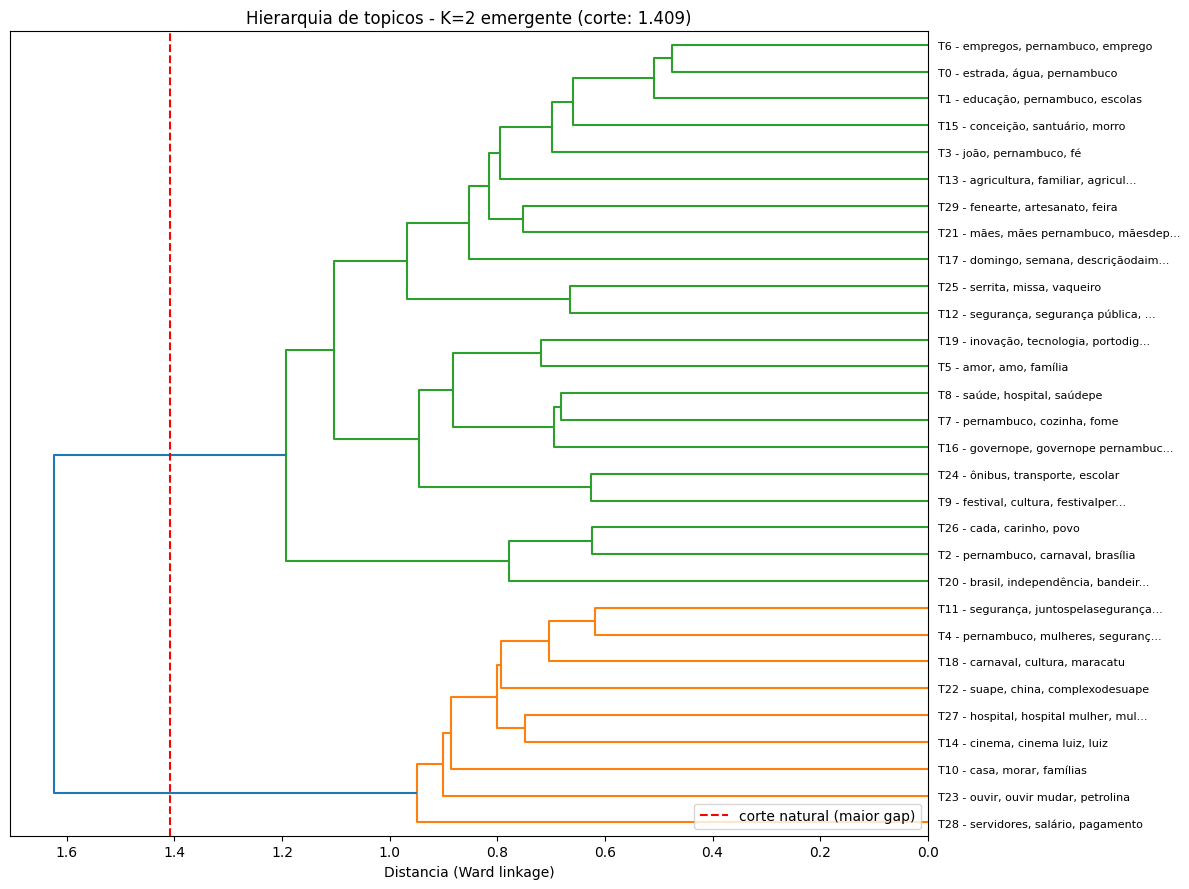

Salvo: ..\data\output\social\bertopic_arvore_macro.png


In [19]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from collections import defaultdict

# === R4 reescrito (NLP review): K *emergente* via maior salto na hierarquia ===
# Em vez de impor K=8, calculamos a linkage Ward sobre topic_embeddings_ e
# cortamos na MAIOR descontinuidade entre niveis. K vira data-driven, coerente
# com a filosofia "deixa o algoritmo descobrir" do BERTopic/HDBSCAN.

def _label_for(tid):
    if "topics_names" in globals() and tid in topics_names:
        return topics_names[tid]
    kws = topics_keywords.get(tid, [])
    return ", ".join(kws[:3]) if kws else "T" + str(tid)


_doc_counts = pd.Series(topics).value_counts()
_doc_counts = _doc_counts[_doc_counts.index != -1]

if hasattr(topic_model, "topic_embeddings_") and topic_model.topic_embeddings_ is not None:
    valid_topic_ids = [t for t in sorted(topic_model.get_topics().keys()) if t != -1]
    topic_emb = topic_model.topic_embeddings_

    all_tids_sorted = sorted(topic_model.get_topics().keys())
    tid_to_idx = {t: i for i, t in enumerate(all_tids_sorted)}

    valid_emb = np.array([topic_emb[tid_to_idx[t]] for t in valid_topic_ids])

    norms = np.linalg.norm(valid_emb, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    valid_emb_norm = valid_emb / norms

    Z = linkage(valid_emb_norm, method="ward")

    # Maior gap entre distancias consecutivas dos merges (Z[:, 2] = distancia)
    merge_distances = Z[:, 2]
    gaps = np.diff(merge_distances)
    biggest_gap_idx = int(np.argmax(gaps))
    cut_distance = (merge_distances[biggest_gap_idx] + merge_distances[biggest_gap_idx + 1]) / 2.0

    macro_labels = fcluster(Z, t=cut_distance, criterion="distance")
    K_EMERGENT = int(np.max(macro_labels))

    print("=== Macro-temas (K emergente, sem imposicao manual) ===")
    print("Maior gap nas distancias: " + str(round(float(gaps[biggest_gap_idx]), 4)))
    print("Distancia de corte (data-driven): " + str(round(float(cut_distance), 4)))
    print("K emergente: " + str(K_EMERGENT) + " macro-temas")
    print()

    micro_to_macro = dict(zip(valid_topic_ids, macro_labels.tolist()))
    macro_to_micros = defaultdict(list)
    for micro, macro in micro_to_macro.items():
        macro_to_micros[macro].append(micro)

    for macro_id in sorted(macro_to_micros.keys()):
        micros = sorted(macro_to_micros[macro_id], key=lambda t: -int(_doc_counts.get(t, 0)))
        total_docs = sum(int(_doc_counts.get(t, 0)) for t in micros)

        macro_keywords = []
        for t in micros[:3]:
            macro_keywords.extend(topics_keywords.get(t, [])[:2])
        seen = set()
        macro_label_terms = []
        for kw in macro_keywords:
            if kw not in seen:
                seen.add(kw)
                macro_label_terms.append(kw)
        macro_label = ", ".join(macro_label_terms[:5])

        print("Macro-tema " + str(macro_id) + " (" + str(total_docs) + " docs, " + str(len(micros)) + " sub-topicos)")
        print("   Keywords agregadas: " + macro_label)
        for t in micros:
            n = int(_doc_counts.get(t, 0))
            label = _label_for(t)[:50]
            print("     T" + str(t).rjust(2) + " (" + str(n).rjust(4) + " docs)  " + label)
        print()

    macro_df = pd.DataFrame([
        {
            "topic_id": t,
            "macro_id": int(micro_to_macro[t]),
            "topic_name": _label_for(t),
            "n_docs": int(_doc_counts.get(t, 0)),
        }
        for t in valid_topic_ids
    ]).sort_values(["macro_id", "n_docs"], ascending=[True, False])
    macro_df.to_csv(RESULTS_DIR / "bertopic_macro_temas.csv", index=False)
    print("Salvo: " + str(RESULTS_DIR / "bertopic_macro_temas.csv"))

    fig, ax = plt.subplots(figsize=(12, max(6, 0.30 * len(valid_topic_ids))))
    labels_for_plot = []
    for t in valid_topic_ids:
        nm = _label_for(t)
        if len(nm) > 30:
            nm = nm[:30] + "..."
        labels_for_plot.append("T" + str(t) + " - " + nm)
    dendrogram(
        Z, labels=labels_for_plot, orientation="left",
        leaf_font_size=8, color_threshold=cut_distance, ax=ax,
    )
    ax.axvline(x=cut_distance, color="red", linestyle="--", linewidth=1.5,
               label="corte natural (maior gap)")
    ax.set_title("Hierarquia de topicos - K=" + str(K_EMERGENT) + " emergente (corte: " + str(round(float(cut_distance), 3)) + ")")
    ax.set_xlabel("Distancia (Ward linkage)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "bertopic_arvore_macro.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo: " + str(RESULTS_DIR / "bertopic_arvore_macro.png"))
else:
    print("topic_embeddings_ indisponivel - pulando R4.")


## V2 — Sankey: consolidação de tópicos pelo `reduce_topics`

Diagrama de Sankey mostrando como os tópicos descobertos pelo HDBSCAN foram
**consolidados** pelo `reduce_topics(nr_topics=N)`. Cada fluxo conecta um
tópico original a um tópico final, com largura proporcional ao número de
documentos.

Útil para a dissertação:
- Documenta visualmente a redução de granularidade (54 → 29 no run final)
- Mostra que tópicos "irmãos" foram absorvidos pelo mesmo cluster final
  (ex: 6 sub-tópicos de Segurança Pública → 1 tópico T3 consolidado)

Usa `topic_model.topic_mapper_.get_mappings()` para reconstruir o mapping.


In [31]:
try:
    import plotly.graph_objects as go
    mapper = getattr(topic_model, "topic_mapper_", None)
    mappings = mapper.get_mappings() if mapper else None
except Exception as _e:
    mappings = None

if mappings and len(mappings) > 0:
    # Mappings é um dict {topico_original: topico_final}
    # Excluir outliers (-1) se presentes
    flow_counts: dict = {}
    for tid_orig, tid_final in mappings.items():
        if tid_orig == -1 or tid_final == -1:
            continue
        flow_counts[(tid_orig, tid_final)] = flow_counts.get((tid_orig, tid_final), 0) + 1

    if flow_counts:
        # Para Sankey, usamos a contagem real de docs no tópico original (estimada)
        # como peso do fluxo. Sem essa info preservada, usamos contagem unitária.
        orig_ids = sorted({o for o, _ in flow_counts.keys()})
        final_ids = sorted({f for _, f in flow_counts.keys()})

        node_labels = (
            [f"orig T{t}" for t in orig_ids]
            + [f"final T{t} — {topics_names.get(t, '')[:30]}" for t in final_ids]
        )
        orig_idx = {t: i for i, t in enumerate(orig_ids)}
        final_idx = {t: i + len(orig_ids) for i, t in enumerate(final_ids)}

        sources, targets, values = [], [], []
        for (o, f), v in flow_counts.items():
            sources.append(orig_idx[o])
            targets.append(final_idx[f])
            values.append(v)

        fig = go.Figure(data=[go.Sankey(
            arrangement="snap",
            node=dict(
                pad=15, thickness=18,
                line=dict(color="#888", width=0.5),
                label=node_labels,
                color="rgba(70, 130, 180, 0.7)",
            ),
            link=dict(source=sources, target=targets, value=values,
                      color="rgba(180, 180, 220, 0.4)"),
        )])
        fig.update_layout(
            title_text=f"Consolidação de tópicos: {len(orig_ids)} originais → {len(final_ids)} finais",
            font_size=10, height=max(500, 25 * max(len(orig_ids), len(final_ids))),
        )
        fig.write_html(RESULTS_DIR / "bertopic_sankey_reduce_topics.html")
        fig.show()
        print(f"Salvo: {RESULTS_DIR / 'bertopic_sankey_reduce_topics.html'}")
    else:
        print("V2: nenhum fluxo de redução encontrado (reduce_topics não foi aplicado).")
else:
    print("V2: topic_mapper_ vazio ou indisponível — reduce_topics não foi aplicado.")


Salvo: ..\data\output\social\bertopic_sankey_reduce_topics.html


## V7 — `visualize_documents` interativo com dropdown "Isolar tópico"

Versão **interativa Plotly** do mapa de documentos, com:
- Hover mostrando snippet do post
- **Dropdown** para isolar um tópico (esconde os outros) ou mostrar todos

Diferente da V6 (estática para PDF), a V7 é para exploração ao vivo —
útil para a defesa demonstrar tópicos sobrepostos ou validar atribuições.
Salvo em `bertopic_documents_interactive.html`.


In [38]:
import plotly.graph_objects as go

# Reutilizar embeddings dos docs (se BERTopic guardou) ou usar os ja carregados
doc_embeddings_for_v7 = embeddings

fig_docs_interactive = topic_model.visualize_documents(
    docs_raw if "docs_raw" in globals() else docs,
    embeddings=doc_embeddings_for_v7,
    hide_annotations=False,
    hide_document_hover=False,
)

# Adicionar dropdown "Isolar topico"
n_traces = len(fig_docs_interactive.data)
trace_names = [str(tr.name) for tr in fig_docs_interactive.data]

botoes = [dict(
    label="Todos os topicos",
    method="update",
    args=[{"visible": [True] * n_traces}],
)]

for i, name in enumerate(trace_names):
    visibility = [False] * n_traces
    visibility[i] = True
    botoes.append(dict(
        label=f"Isolar: {name[:40]}",
        method="update",
        args=[{"visible": visibility}],
    ))

fig_docs_interactive.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        buttons=botoes,
        showactive=True,
        x=0.01, xanchor="left",
        y=1.12, yanchor="top",
        bgcolor="white",
        bordercolor="#888",
    )],
    annotations=list(fig_docs_interactive.layout.annotations or []) + [
        dict(
            text="<b>Isolar topico (dropdown)</b>",
            x=0.01, xref="paper",
            y=1.18, yref="paper",
            showarrow=False,
            font=dict(size=11),
        )
    ],
    margin=dict(t=120),
)

out_html_v7 = RESULTS_DIR / "bertopic_documents_interactive.html"
fig_docs_interactive.write_html(out_html_v7)
fig_docs_interactive.show()
print(f"Salvo: {out_html_v7}")


Salvo: ..\data\output\social\bertopic_documents_interactive.html


## 12. Export final

In [ ]:
# Cell 18 — Export CSVs
out_dir = f"../data/output/{CORPUS_ID}"
os.makedirs(out_dir, exist_ok=True)

# Build dummy probability matrix
probs_dummy = [[1.0 if t == tid else 0.0 for tid in sorted(topics_keywords)] for t in topics]

# Wrap topic_id -> include outlier as last
topic_id_for_export = [t if t != -1 else max(topics_keywords) + 1 for t in topics]
names_export = dict(names)
names_export[max(topics_keywords) + 1] = "Outlier"

export_results(
    topics=topic_id_for_export, probs=probs_dummy, names=names_export,
    texts=docs, output_path=f"{out_dir}/bertopic_results.csv",
    topic_type="semantic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="bertopic", output_path=f"{out_dir}/bertopic_topics_for_eval.csv",
)
pd.DataFrame([metrics]).to_csv(f"{out_dir}/bertopic_metrics.csv", index=False)

# Save BERTopic model
try:
    topic_model.save(f"{out_dir}/bertopic_model",
                     serialization="safetensors", save_ctfidf=True, save_embedding_model=False)
    print(f"saved model: {out_dir}/bertopic_model/")
except Exception as e:
    print(f"could not save model: {e}")

print(f"\nCSVs em {out_dir}/")
for f in ["bertopic_results.csv", "bertopic_topics_for_eval.csv", "bertopic_metrics.csv"]:
    p = f"{out_dir}/{f}"
    if os.path.exists(p):
        print(f"  {f} ({os.path.getsize(p)/1024:.0f} KB)")

## Próximos passos

- Comparar com Reuters (`02_lda_reuters.ipynb`, `04_stm_reuters.ipynb`) — outros modelos no mesmo corpus EN
- Aplicar mesmo template em Tweets eleições 2022 BR (PT-BR, ~7M tweets, sample 200k)

## Referências

- **Grootendorst, M. (2022)**. *BERTopic: Neural topic modeling with a class-based TF-IDF procedure*. arXiv:2203.05794
- **Zhang, X., Zhao, J., LeCun, Y. (2015)**. *Character-level Convolutional Networks for Text Classification*. NIPS — AG News dataset
- **McInnes, L., Healy, J., Melville, J. (2018)**. *UMAP: Uniform Manifold Approximation and Projection*
- **Campello, R. J. G. B., Moulavi, D., Sander, J. (2013)**. *Density-Based Clustering Based on Hierarchical Density Estimates* — HDBSCAN
